## Simple Covariance Matrix

In [8]:
import numpy as np

# Suppose we have 5 "sample" observations (rows) of 2 variables (columns)
# Each row = one observation [x, y] - x: Hours studied, y: Test score
data = np.array([
    [2, 65],
    [4, 70],
    [6, 75],
    [8, 80],
    [10, 85],
])

# Transpose the data so that variables are rows
# Each row = variable, each column = observation

cov_matrix = np.cov(data.T)

print("Data:\n", data)
print("Transposed Data: \n", data.T)
print("\nCovariance matrix:\n", cov_matrix)


Data:
 [[ 2 65]
 [ 4 70]
 [ 6 75]
 [ 8 80]
 [10 85]]
Transposed Data: 
 [[ 2  4  6  8 10]
 [65 70 75 80 85]]

Covariance matrix:
 [[10.  25. ]
 [25.  62.5]]


In [9]:
# Compute the covariance matrix manually
# Formula: Cov(X, Y) = Σ[(xi - x̄)(yi - ȳ)] / (n - 1)
data_manual = np.array([
    [2, 65],     [4, 70],     [6, 75],     [8, 80],     [10, 85]        ])
n = data_manual.shape[0] # Number of observations

# Calculate the means for each variable
mean_x = np.mean(data_manual[:, 0])
mean_y = np.mean(data_manual[:, 1])

# Calculate the covariance between X and Y
cov_xy = np.sum((data_manual[:, 0] - mean_x) * (data_manual[:, 1] - mean_y)) / (n - 1)

# Calculate the variance of X (covariance of X with itself)
var_x = np.sum((data_manual[:, 0] - mean_x)**2) / (n - 1)

# Calculate the variance of Y (covariance of Y with itself)
var_y = np.sum((data_manual[:, 1] - mean_y)**2) / (n - 1)

# Construct the covariance matrix
covariance_matrix_manual = np.array([
    [var_x, cov_xy],
    [cov_xy, var_y]
])
print("\nManual Covariance matrix:\n", covariance_matrix_manual)


Manual Covariance matrix:
 [[10.  25. ]
 [25.  62.5]]


Data:
 [[15 18 20 22 25 27 30 32 35 36]
 [ 2 12 26 35 40 55 70 82 96 98]
 [50 40 30 20 18 16 14 13 12 10]]
Covariance matrix:
[[  52.44  246.33  -87.78]
 [ 246.33 1165.82 -407.64]
 [ -87.78 -407.64  179.57]]


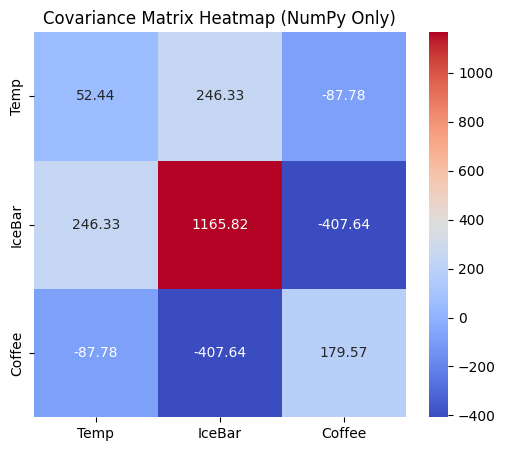

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Example: 10 days. Variables are rows!
temperature =   np.array([15, 18, 20, 22, 25, 27, 30, 32, 35, 36])
iceBars =       np.array([2,  12, 26, 35, 40, 55, 70, 82, 96, 98]) # num sold
hotCoffeeCups = np.array([50, 40, 30, 20, 18, 16, 14, 13, 12, 10]) # num sold

# Stack into 2D array: each row = variable, each column = observation
data = np.vstack((temperature, iceBars, hotCoffeeCups))
print("Data:\n", data)

cov_matrix = np.cov(data) # variables as rows; rowvar=True by default
print(f"Covariance matrix:\n{np.array2string(cov_matrix, precision=2)}")

plt.figure(figsize=(6, 5))
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=["Temp", "IceBar", "Coffee"],
            yticklabels=["Temp", "IceBar", "Coffee"])
plt.title("Covariance Matrix Heatmap (NumPy Only)")
plt.show()


Manual Correlation matrix converted from Covariance matrix:
[[ 1.    1.   -0.9 ]
 [ 1.    1.   -0.89]
 [-0.9  -0.89  1.  ]]


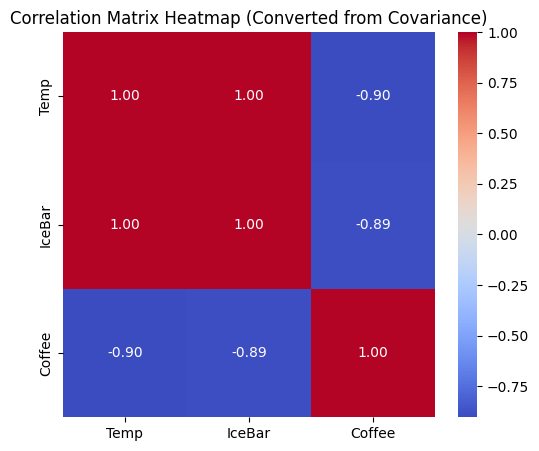

In [11]:
# Convert a covariance matrix to a correlation matrix manually
# Formula: Corr(X, Y) = Cov(X, Y) / (std(X) * std(Y))
# Where std(X) = sqrt(Var(X)) and Var(X) is the diagonal element of the covariance matrix

# Get the variances from the diagonal of the covariance matrix
variances = np.diag(cov_matrix)

# Calculate the standard deviations from the variances
standard_deviations = np.sqrt(variances)

# Initialize an empty correlation matrix
n_vars = cov_matrix.shape[0]
correlation_matrix_converted = np.zeros((n_vars, n_vars))

# Populate the correlation matrix using the formula
for i in range(n_vars):
    for j in range(n_vars):
        covariance_ij = cov_matrix[i, j]
        std_i = standard_deviations[i]
        std_j = standard_deviations[j]

        # Handle the case where standard deviation might be zero to avoid division by zero
        if std_i != 0 and std_j != 0:
            correlation_matrix_converted[i, j] = covariance_ij / (std_i * std_j)
        else:
            correlation_matrix_converted[i, j] = 0.0 # Or np.nan, depending on desired behavior for zero variance

print(f"\nManual Correlation matrix converted from Covariance matrix:\n{np.array2string(correlation_matrix_converted, precision=2)}")

# Optional: Visualize the converted correlation matrix
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix_converted, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=["Temp", "IceBar", "Coffee"],
            yticklabels=["Temp", "IceBar", "Coffee"])
plt.title("Correlation Matrix Heatmap (Converted from Covariance)")
plt.show()


Correlation matrix:
[[ 1.    1.   -0.9 ]
 [ 1.    1.   -0.89]
 [-0.9  -0.89  1.  ]]


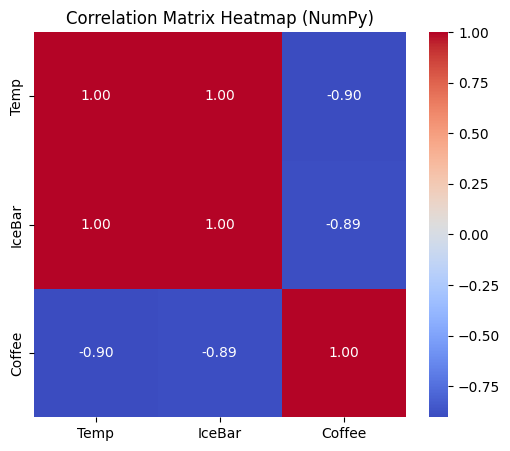

In [13]:
# Compute the correlation matrix
correlation_matrix = np.corrcoef(data)

print(f"\nCorrelation matrix:\n{np.array2string(correlation_matrix, precision=2)}")

# Visualize the correlation matrix
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=["Temp", "IceBar", "Coffee"],
            yticklabels=["Temp", "IceBar", "Coffee"])
plt.title("Correlation Matrix Heatmap (NumPy)")
plt.show()